In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import json
import warnings
from pathlib import Path

In [2]:
warnings.filterwarnings("ignore")

# Set display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


def load_dataset(file_path: str) -> pd.DataFrame:
    """
    Load the banking dataset from CSV file.

    Args:
        file_path (str): Path to the CSV file

    Returns:
        pd.DataFrame: Loaded dataset
    """
    df = pd.read_csv(file_path)
    print(f"Dataset loaded successfully!")
    print(f"Dataset shape: {df.shape}")
    print(f"\nMissing values:\n{df.isnull().sum()}")
    return df


def assign_age_group(age: int) -> str:
    """
    Assign customers to age groups based on their age.

    Args:
        age (int): Customer age

    Returns:
        str: Age group label
    """
    if age < 25:
        return "18-24: Gen Z / Young Adults"
    elif age < 35:
        return "25-34: Young Professionals"
    elif age < 50:
        return "35-49: Established Professionals"
    elif age < 60:
        return "50-59: Pre-Retirement"
    else:
        return "60+: Retirement"


def apply_age_grouping(df: pd.DataFrame) -> pd.DataFrame:
    """
    Apply age grouping to the dataset.

    Args:
        df (pd.DataFrame): Input dataframe

    Returns:
        pd.DataFrame: Dataframe with Age_Group column added
    """
    df["Age_Group"] = df["Age"].apply(assign_age_group)

    print("Age Group Distribution:")
    age_group_counts = df["Age_Group"].value_counts()
    print(age_group_counts)
    print(f"\nPercentage Distribution:")
    print((age_group_counts / len(df) * 100).round(2))

    return df

In [3]:
def visualize_age_groups(df: pd.DataFrame) -> None:
    """
    Visualize age group distribution with bar and pie charts.

    Args:
        df (pd.DataFrame): Input dataframe with Age_Group column
    """
    age_group_counts = df["Age_Group"].value_counts()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Bar plot
    age_group_counts.plot(kind="bar", ax=ax1, color="steelblue")
    ax1.set_title("Customer Distribution by Age Group", fontsize=12, fontweight="bold")
    ax1.set_xlabel("Age Group")
    ax1.set_ylabel("Count")
    ax1.tick_params(axis="x", rotation=45)

    # Pie chart
    ax2.pie(
        age_group_counts.values,
        labels=age_group_counts.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=sns.color_palette("husl", len(age_group_counts)),
    )
    ax2.set_title("Age Group Distribution (%)", fontsize=12, fontweight="bold")

    plt.tight_layout()
    plt.show()

In [4]:
def create_customer_profile(group_df: pd.DataFrame) -> dict:
    """
    Create aggregated profile statistics for an age group.

    Args:
        group_df (pd.DataFrame): Dataframe containing customers from one age group

    Returns:
        dict: Profile statistics dictionary
    """
    profile = {
        "count": len(group_df),
        "avg_age": group_df["Age"].mean(),
        "avg_account_balance": group_df["Account Balance"].mean(),
        "avg_loan_amount": group_df["Loan Amount"].mean(),
        "avg_credit_limit": group_df["Credit Limit"].mean(),
        "avg_credit_balance": group_df["Credit Card Balance"].mean(),
        "loan_approval_rate": (group_df["Loan Status"] == "Approved").sum()
        / len(group_df),
        "avg_interest_rate": group_df["Interest Rate"].mean(),
        "account_types": group_df["Account Type"].value_counts().to_dict(),
        "dominant_loan_type": (
            group_df["Loan Type"].mode()[0]
            if len(group_df["Loan Type"].mode()) > 0
            else "N/A"
        ),
        "avg_transaction_amount": group_df["Transaction Amount"].mean(),
    }
    return profile


def create_age_group_profiles(df: pd.DataFrame) -> dict:
    """
    Create customer profiles for all age groups.

    Args:
        df (pd.DataFrame): Input dataframe with Age_Group column

    Returns:
        dict: Dictionary mapping age groups to their profiles
    """
    age_group_profiles = {}

    for age_group in sorted(df["Age_Group"].unique()):
        group_df = df[df["Age_Group"] == age_group]
        age_group_profiles[age_group] = create_customer_profile(group_df)

    print("Customer Profiles by Age Group:\n")
    for age_group, profile in age_group_profiles.items():
        print(f"\n{'='*70}")
        print(f"Age Group: {age_group}")
        print(f"{'='*70}")
        print(f"Customer Count: {profile['count']}")
        print(f"Average Age: {profile['avg_age']:.1f} years")
        print(f"Average Account Balance: ${profile['avg_account_balance']:.2f}")
        print(f"Average Loan Amount: ${profile['avg_loan_amount']:.2f}")
        print(f"Average Credit Limit: ${profile['avg_credit_limit']:.2f}")
        print(f"Average Credit Card Balance: ${profile['avg_credit_balance']:.2f}")
        print(f"Loan Approval Rate: {profile['loan_approval_rate']*100:.1f}%")
        print(f"Average Interest Rate: {profile['avg_interest_rate']:.2f}%")
        print(f"Dominant Loan Type: {profile['dominant_loan_type']}")
        print(f"Average Transaction Amount: ${profile['avg_transaction_amount']:.2f}")

    return age_group_profiles

In [5]:
def create_comparison_dataframe(age_group_profiles: dict) -> pd.DataFrame:
    """
    Create a comparison dataframe for all age groups.

    Args:
        age_group_profiles (dict): Dictionary of age group profiles

    Returns:
        pd.DataFrame: Comparison dataframe
    """
    comparison_df = pd.DataFrame(
        {
            "Age_Group": list(age_group_profiles.keys()),
            "Customer_Count": [
                profile["count"] for profile in age_group_profiles.values()
            ],
            "Avg_Account_Balance": [
                profile["avg_account_balance"]
                for profile in age_group_profiles.values()
            ],
            "Avg_Loan_Amount": [
                profile["avg_loan_amount"] for profile in age_group_profiles.values()
            ],
            "Avg_Credit_Limit": [
                profile["avg_credit_limit"] for profile in age_group_profiles.values()
            ],
            "Loan_Approval_Rate": [
                profile["loan_approval_rate"] for profile in age_group_profiles.values()
            ],
            "Avg_Interest_Rate": [
                profile["avg_interest_rate"] for profile in age_group_profiles.values()
            ],
        }
    )

    print("Age Group Comparison Summary:")
    print(comparison_df.to_string())

    return comparison_df


def visualize_financial_metrics(df: pd.DataFrame) -> None:
    """
    Visualize financial metrics by age group.

    Args:
        df (pd.DataFrame): Input dataframe with Age_Group column
    """
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))

    # Account Balance by Age Group
    df.boxplot(column="Account Balance", by="Age_Group", ax=axes[0, 0])
    axes[0, 0].set_title("Account Balance Distribution")
    axes[0, 0].set_xlabel("Age Group")
    axes[0, 0].set_ylabel("Balance ($)")

    # Loan Amount by Age Group
    df.boxplot(column="Loan Amount", by="Age_Group", ax=axes[0, 1])
    axes[0, 1].set_title("Loan Amount Distribution")
    axes[0, 1].set_xlabel("Age Group")
    axes[0, 1].set_ylabel("Loan Amount ($)")

    # Credit Limit by Age Group
    df.boxplot(column="Credit Limit", by="Age_Group", ax=axes[0, 2])
    axes[0, 2].set_title("Credit Limit Distribution")
    axes[0, 2].set_xlabel("Age Group")
    axes[0, 2].set_ylabel("Credit Limit ($)")

    # Interest Rate by Age Group
    df.boxplot(column="Interest Rate", by="Age_Group", ax=axes[1, 0])
    axes[1, 0].set_title("Interest Rate Distribution")
    axes[1, 0].set_xlabel("Age Group")
    axes[1, 0].set_ylabel("Interest Rate (%)")

    # Loan Approval Rate
    approval_rates = df.groupby("Age_Group").apply(
        lambda x: (x["Loan Status"] == "Approved").sum() / len(x) * 100
    )
    approval_rates.plot(kind="bar", ax=axes[1, 1], color="seagreen")
    axes[1, 1].set_title("Loan Approval Rate by Age Group")
    axes[1, 1].set_xlabel("Age Group")
    axes[1, 1].set_ylabel("Approval Rate (%)")
    axes[1, 1].tick_params(axis="x", rotation=45)

    # Transaction Amount by Age Group
    df.boxplot(column="Transaction Amount", by="Age_Group", ax=axes[1, 2])
    axes[1, 2].set_title("Transaction Amount Distribution")
    axes[1, 2].set_xlabel("Age Group")
    axes[1, 2].set_ylabel("Transaction Amount ($)")

    plt.suptitle(
        "Financial Metrics by Age Group", fontsize=14, fontweight="bold", y=1.00
    )
    plt.tight_layout()
    plt.show()

In [6]:
def create_recommendation_prompt(
    customer_row: pd.Series, age_group_profile: dict
) -> str:
    """
    Generate a recommendation prompt for Phi-3 model based on customer profile.

    Args:
        customer_row (pd.Series): Single customer row
        age_group_profile (dict): Age group profile statistics

    Returns:
        str: Formatted recommendation prompt
    """
    prompt = f"""
Based on the following customer financial profile, provide personalized financial recommendations:

Customer Profile:
- Age Group: {customer_row['Age_Group']}
- Age: {int(customer_row['Age'])} years
- Gender: {customer_row['Gender']}
- Current Account Type: {customer_row['Account Type']}
- Account Balance: ${customer_row['Account Balance']:.2f}
- Existing Loan: ${customer_row['Loan Amount']:.2f} ({customer_row['Loan Type']})
- Interest Rate: {customer_row['Interest Rate']:.2f}%
- Credit Limit: ${customer_row['Credit Limit']:.2f}
- Credit Card Balance: ${customer_row['Credit Card Balance']:.2f}
- Recent Transaction: {customer_row['Transaction Type']} of ${customer_row['Transaction Amount']:.2f}

Age Group Statistics (for context):
- Average Account Balance: ${age_group_profile['avg_account_balance']:.2f}
- Average Loan Amount: ${age_group_profile['avg_loan_amount']:.2f}
- Loan Approval Rate: {age_group_profile['loan_approval_rate']*100:.1f}%
- Average Interest Rate: {age_group_profile['avg_interest_rate']:.2f}%

Please provide:
1. Risk assessment based on age group and financial metrics
2. Recommended account type optimization
3. Loan refinancing opportunities
4. Credit card usage recommendations
5. Investment/savings recommendations appropriate for their age group
"""
    return prompt

In [7]:
def calculate_risk_score(customer_row: pd.Series, age_group_profile: dict) -> tuple:
    """
    Calculate financial risk score for a customer (0-100, higher is riskier).

    Args:
        customer_row (pd.Series): Single customer row
        age_group_profile (dict): Age group profile statistics

    Returns:
        tuple: (risk_score, risk_factors_dict)
    """
    risk_score = 0
    risk_factors = {}

    # Account balance risk (20 points max)
    if customer_row["Account Balance"] < age_group_profile["avg_account_balance"] * 0.5:
        risk_factors["Low Balance"] = 20
        risk_score += 20
    elif customer_row["Account Balance"] < age_group_profile["avg_account_balance"]:
        risk_factors["Below Average Balance"] = 10
        risk_score += 10

    # Credit card utilization risk (20 points max)
    credit_utilization = (
        customer_row["Credit Card Balance"] / customer_row["Credit Limit"]
        if customer_row["Credit Limit"] > 0
        else 0
    )
    if credit_utilization > 0.9:
        risk_factors["Very High Credit Utilization"] = 20
        risk_score += 20
    elif credit_utilization > 0.7:
        risk_factors["High Credit Utilization"] = 15
        risk_score += 15
    elif credit_utilization > 0.5:
        risk_factors["Moderate Credit Utilization"] = 10
        risk_score += 10

    # Interest rate risk (20 points max)
    if customer_row["Interest Rate"] > age_group_profile["avg_interest_rate"] * 1.5:
        risk_factors["High Interest Rate"] = 20
        risk_score += 20
    elif customer_row["Interest Rate"] > age_group_profile["avg_interest_rate"]:
        risk_factors["Above Average Rate"] = 10
        risk_score += 10

    # Loan status risk (20 points max)
    if customer_row["Loan Status"] == "Rejected":
        risk_factors["Rejected Loan"] = 20
        risk_score += 20
    elif customer_row["Loan Status"] == "Pending":
        risk_factors["Pending Loan"] = 10
        risk_score += 10

    # Age consideration risk (20 points max)
    age = customer_row["Age"]
    if age < 25:
        risk_factors["Inexperienced Age"] = 15
        risk_score += 15
    elif age > 65:
        risk_factors["Approaching Retirement"] = 10
        risk_score += 10

    return min(risk_score, 100), risk_factors


def add_risk_scores(df: pd.DataFrame, age_group_profiles: dict) -> pd.DataFrame:
    """
    Add risk scores to the dataframe.

    Args:
        df (pd.DataFrame): Input dataframe
        age_group_profiles (dict): Dictionary of age group profiles

    Returns:
        pd.DataFrame: Dataframe with Risk_Score column added
    """
    risk_scores = []
    risk_details = []

    for idx, row in df.iterrows():
        age_group_profile = age_group_profiles[row["Age_Group"]]
        risk_score, risk_factors = calculate_risk_score(row, age_group_profile)
        risk_scores.append(risk_score)
        risk_details.append(risk_factors)

    df["Risk_Score"] = risk_scores

    print("Risk Score Statistics by Age Group:")
    risk_by_age = df.groupby("Age_Group")["Risk_Score"].agg(
        ["mean", "min", "max", "std"]
    )
    print(risk_by_age)

    return df

In [8]:
def visualize_risk_scores(df: pd.DataFrame) -> None:
    """
    Visualize risk scores distribution and by age group.

    Args:
        df (pd.DataFrame): Input dataframe with Risk_Score column
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Distribution of risk scores
    axes[0].hist(df["Risk_Score"], bins=30, color="coral", edgecolor="black")
    axes[0].set_title("Distribution of Risk Scores", fontsize=12, fontweight="bold")
    axes[0].set_xlabel("Risk Score (0-100)")
    axes[0].set_ylabel("Frequency")
    axes[0].axvline(
        df["Risk_Score"].mean(),
        color="red",
        linestyle="--",
        label=f'Mean: {df["Risk_Score"].mean():.2f}',
    )
    axes[0].legend()

    # Risk scores by age group
    df.boxplot(column="Risk_Score", by="Age_Group", ax=axes[1])
    axes[1].set_title("Risk Score Distribution by Age Group")
    axes[1].set_xlabel("Age Group")
    axes[1].set_ylabel("Risk Score")

    plt.suptitle("Financial Risk Assessment", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

In [9]:
def create_training_dataset_csv(
    df: pd.DataFrame, age_group_profiles: dict, output_path: str
) -> pd.DataFrame:
    """
    Create and save training dataset in CSV format.

    Args:
        df (pd.DataFrame): Input dataframe
        age_group_profiles (dict): Dictionary of age group profiles
        output_path (str): Path to save CSV file

    Returns:
        pd.DataFrame: Training dataset
    """
    training_dataset = []

    for idx, row in df.iterrows():
        age_group_profile = age_group_profiles[row["Age_Group"]]
        prompt = create_recommendation_prompt(row, age_group_profile)

        training_dataset.append(
            {
                "customer_id": row["Customer ID"],
                "age_group": row["Age_Group"],
                "age": row["Age"],
                "gender": row["Gender"],
                "prompt": prompt,
                "account_balance": row["Account Balance"],
                "loan_amount": row["Loan Amount"],
                "loan_type": row["Loan Type"],
                "interest_rate": row["Interest Rate"],
                "credit_limit": row["Credit Limit"],
                "credit_balance": row["Credit Card Balance"],
                "loan_status": row["Loan Status"],
                "risk_score": row["Risk_Score"],
            }
        )

    training_df = pd.DataFrame(training_dataset)
    training_df.to_csv(output_path, index=False)

    print(f"Training dataset saved to {output_path}! Shape: {training_df.shape}")

    return training_df

In [10]:
def perform_kmeans_clustering(df: pd.DataFrame) -> tuple:
    """
    Perform K-Means clustering on financial features.

    Args:
        df (pd.DataFrame): Input dataframe

    Returns:
        tuple: (df with clusters, kmeans model, scaler)
    """
    clustering_features = [
        "Account Balance",
        "Loan Amount",
        "Credit Limit",
        "Credit Card Balance",
        "Interest Rate",
        "Transaction Amount",
    ]

    # Handle missing values
    df_cluster = df[clustering_features + ["Age_Group"]].fillna(0)

    # Standardize features
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(df_cluster[clustering_features])

    # Apply K-Means clustering
    kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(features_scaled)

    df["Cluster"] = clusters

    print("K-Means Clustering Results:")
    print(f"\nCluster distribution:")
    print(df["Cluster"].value_counts().sort_index())

    return df, kmeans, scaler

In [11]:
def analyze_clusters(df: pd.DataFrame) -> None:
    """
    Analyze and display cluster characteristics.

    Args:
        df (pd.DataFrame): Dataframe with Cluster column
    """
    clustering_features = [
        "Account Balance",
        "Loan Amount",
        "Credit Limit",
        "Credit Card Balance",
        "Interest Rate",
        "Transaction Amount",
    ]

    print("\nCluster Characteristics:\n")

    for cluster in sorted(df["Cluster"].unique()):
        cluster_data = df[df["Cluster"] == cluster]
        age_groups_in_cluster = cluster_data["Age_Group"].value_counts()

        print(f"\n{'='*70}")
        print(f"Cluster {cluster} (Size: {len(cluster_data)} customers)")
        print(f"{'='*70}")
        print(f"Average Account Balance: ${cluster_data['Account Balance'].mean():.2f}")
        print(f"Average Loan Amount: ${cluster_data['Loan Amount'].mean():.2f}")
        print(f"Average Credit Limit: ${cluster_data['Credit Limit'].mean():.2f}")
        print(f"Average Interest Rate: {cluster_data['Interest Rate'].mean():.2f}%")
        print(f"\nDominant Age Groups:")
        for age_group, count in age_groups_in_cluster.items():
            print(f"  - {age_group}: {count} ({count/len(cluster_data)*100:.1f}%)")

In [12]:
def create_enhanced_training_data_jsonl(
    df: pd.DataFrame, age_group_profiles: dict, output_path: str
) -> list:
    """
    Create enhanced Phi-3 training data in JSONL format with risk scores.

    Args:
        df (pd.DataFrame): Input dataframe
        age_group_profiles (dict): Dictionary of age group profiles
        output_path (str): Path to save JSONL file

    Returns:
        list: List of training examples
    """
    enhanced_training_data = []

    for idx, row in df.iterrows():
        age_group_profile = age_group_profiles[row["Age_Group"]]
        risk_score = row["Risk_Score"]
        risk_level = (
            "Low" if risk_score < 30 else "Medium" if risk_score < 60 else "High"
        )

        training_example = {
            "messages": [
                {
                    "role": "system",
                    "content": "You are an expert financial advisor specializing in age-group-based recommendations. Provide personalized, data-driven financial guidance considering risk profiles, demographic factors, and financial goals.",
                },
                {
                    "role": "user",
                    "content": f"""Provide comprehensive financial recommendations for:

CUSTOMER PROFILE:
- Age Group: {row['Age_Group']} (Age: {int(row['Age'])})
- Gender: {row['Gender']}
- Risk Level: {risk_level} (Score: {risk_score}/100)

FINANCIAL METRICS:
- Account Balance: ${row['Account Balance']:.2f}
- Loan Amount: ${row['Loan Amount']:.2f} ({row['Loan Type']})
- Interest Rate: {row['Interest Rate']:.2f}%
- Credit Limit: ${row['Credit Limit']:.2f}
- Credit Card Balance: ${row['Credit Card Balance']:.2f}
- Loan Status: {row['Loan Status']}

AGE GROUP BENCHMARKS:
- Average Account Balance: ${age_group_profile['avg_account_balance']:.2f}
- Average Loan Amount: ${age_group_profile['avg_loan_amount']:.2f}
- Loan Approval Rate: {age_group_profile['loan_approval_rate']*100:.1f}%
- Average Interest Rate: {age_group_profile['avg_interest_rate']:.2f}%

Please provide detailed recommendations addressing: risk mitigation, product optimization, debt management, and age-appropriate financial planning.""",
                },
                {
                    "role": "assistant",
                    "content": f"""PERSONALIZED FINANCIAL RECOMMENDATIONS FOR {row['Age_Group'].upper()}

RISK ASSESSMENT (Score: {risk_score}/100 - {risk_level} Risk):
Your financial profile indicates a {risk_level.lower()} risk level. Your account balance is {'above' if row['Account Balance'] > age_group_profile['avg_account_balance'] else 'below'} the age group average of ${age_group_profile['avg_account_balance']:.2f}.

ACCOUNT OPTIMIZATION:
Your current {row['Account Type']} account with ${row['Account Balance']:.2f} balance {'is well-positioned' if row['Account Balance'] > age_group_profile['avg_account_balance'] else 'needs attention'}. Consider {'maintaining or increasing savings' if row['Account Balance'] > age_group_profile['avg_account_balance'] else 'building an emergency fund'}.

LOAN & DEBT MANAGEMENT:
Your {row['Loan Type']} loan at {row['Interest Rate']:.2f}% is {'favorable' if row['Interest Rate'] < age_group_profile['avg_interest_rate'] else 'above your age group average of ' + str(age_group_profile['avg_interest_rate'])}%. Current status: {row['Loan Status']}.

CREDIT MANAGEMENT:
Your credit utilization rate is {row['Credit Card Balance']/row['Credit Limit']*100:.1f}%. Aim to keep this below 30% for optimal credit health.

AGE-APPROPRIATE GOALS:
Focus on: {'Building financial independence and emergency savings' if row['Age'] < 30 else 'Balanced investment growth and retirement planning' if row['Age'] < 55 else 'Wealth preservation and retirement income optimization'}.

RECOMMENDED ACTIONS:
1. {'Increase savings rate and build credit history' if row['Age'] < 30 else 'Maximize retirement contributions' if row['Age'] > 50 else 'Balance debt payoff with investment growth'}
2. {'Review and reduce credit card usage' if row['Credit Card Balance']/row['Credit Limit'] > 0.5 else 'Maintain responsible credit habits'}
3. {'Consider consolidating high-interest debt' if row['Interest Rate'] > age_group_profile['avg_interest_rate'] * 1.2 else 'Monitor interest rate trends'}""",
                },
            ],
            "age_group": row["Age_Group"],
            "risk_score": risk_score,
            "risk_level": risk_level,
        }
        enhanced_training_data.append(training_example)

    # Save as JSON Lines format
    with open(output_path, "w") as f:
        for item in enhanced_training_data:
            f.write(json.dumps(item) + "\n")

    print(
        f"Enhanced training data saved to {output_path}! ({len(enhanced_training_data)} examples)"
    )

    return enhanced_training_data

In [13]:
def create_age_group_summary(df: pd.DataFrame, output_path: str) -> pd.DataFrame:
    """
    Create and save age group summary statistics.

    Args:
        df (pd.DataFrame): Input dataframe
        output_path (str): Path to save CSV file

    Returns:
        pd.DataFrame: Summary statistics dataframe
    """
    summary_stats = []

    for age_group in sorted(df["Age_Group"].unique()):
        group_data = df[df["Age_Group"] == age_group]

        stats = {
            "Age_Group": age_group,
            "Customer_Count": len(group_data),
            "Min_Age": group_data["Age"].min(),
            "Max_Age": group_data["Age"].max(),
            "Avg_Age": group_data["Age"].mean(),
            "Avg_Account_Balance": group_data["Account Balance"].mean(),
            "Median_Account_Balance": group_data["Account Balance"].median(),
            "Avg_Loan_Amount": group_data["Loan Amount"].mean(),
            "Avg_Credit_Limit": group_data["Credit Limit"].mean(),
            "Avg_Interest_Rate": group_data["Interest Rate"].mean(),
            "Avg_Risk_Score": group_data["Risk_Score"].mean(),
            "Total_Transactions": len(group_data),
            "Avg_Transaction_Amount": group_data["Transaction Amount"].mean(),
            "Approved_Loans": (group_data["Loan Status"] == "Approved").sum(),
            "Rejected_Loans": (group_data["Loan Status"] == "Rejected").sum(),
            "Approval_Rate_%": (group_data["Loan Status"] == "Approved").sum()
            / len(group_data)
            * 100,
        }
        summary_stats.append(stats)

    summary_df = pd.DataFrame(summary_stats)
    summary_df.to_csv(output_path, index=False)

    print("Age Group Summary Statistics:")
    print(summary_df.to_string())

    return summary_df

In [14]:
def print_final_summary(
    df: pd.DataFrame,
    training_df: pd.DataFrame,
    enhanced_data_count: int,
    age_group_profiles: dict,
) -> None:
    """
    Print comprehensive final summary report.

    Args:
        df (pd.DataFrame): Main dataframe
        training_df (pd.DataFrame): Training dataset
        enhanced_data_count (int): Count of enhanced training examples
        age_group_profiles (dict): Age group profiles dictionary
    """
    print("\n" + "=" * 80)
    print("FINAL SUMMARY - PHI-3 FINANCIAL RECOMMENDATION MODEL")
    print("=" * 80)

    print(
        f"""
DATASET OVERVIEW:
- Total Customers: {len(df):,}
- Age Range: {df['Age'].min()} - {df['Age'].max()} years
- Account Balance Range: ${df['Account Balance'].min():.2f} - ${df['Account Balance'].max():.2f}
- Total Loan Portfolio: ${df['Loan Amount'].sum():,.2f}
- Average Loan Approval Rate: {(df['Loan Status'] == 'Approved').sum() / len(df) * 100:.1f}%
- Average Risk Score: {df['Risk_Score'].mean():.2f}/100

AGE GROUP BREAKDOWN:
"""
    )

    for age_group in sorted(df["Age_Group"].unique()):
        group_data = df[df["Age_Group"] == age_group]
        print(f"\n{age_group}")
        print(f"  • Customers: {len(group_data)} ({len(group_data)/len(df)*100:.1f}%)")
        print(f"  • Avg Balance: ${group_data['Account Balance'].mean():.2f}")
        print(f"  • Avg Loan: ${group_data['Loan Amount'].mean():.2f}")
        print(
            f"  • Loan Approval Rate: {(group_data['Loan Status'] == 'Approved').sum() / len(group_data) * 100:.1f}%"
        )
        print(f"  • Avg Risk Score: {group_data['Risk_Score'].mean():.2f}/100")

    print(f"\n\n{'='*80}")
    print("FILES GENERATED FOR PHI-3 TRAINING:")
    print("=" * 80)
    print(
        f"""
1. data/phi3_training_data.csv ({len(training_df)} rows)
   - Basic training dataset with customer profiles and prompts
   - Format: CSV with columns for customer data and recommendation prompts

2. data/phi3_enhanced_training_data.jsonl ({enhanced_data_count} examples)
   - Advanced training data with system/user/assistant roles
   - Includes risk scores and comprehensive recommendations
   - Format: JSON Lines, optimized for Phi-3 fine-tuning

3. data/banking_data_with_clusters.csv ({len(df)} rows)
   - Full dataset with age groups, risk scores, and K-Means clusters
   - Format: CSV for comprehensive analysis

4. data/age_group_summary.csv
   - Statistical summary aggregated by age group
   - Format: CSV with key metrics for benchmarking

RECOMMENDED NEXT STEPS:

✓ Use phi3_enhanced_training_data.jsonl for model fine-tuning
✓ Each training example includes system prompt, user query, and expected response
✓ Data is stratified by age groups for specialized recommendations
✓ Risk scores pre-calculated for each customer profile
✓ Total training examples: {len(df):,}

MODEL FINE-TUNING STRATEGY:

Option 1: Single Model (Recommended for general use)
- Train on phi3_enhanced_training_data.jsonl
- Model learns age-group patterns and provides specialized recommendations

Option 2: Age-Group Specific Models
- Filter data by age group and create separate training sets
- Train individual models for each demographic segment
- Deploy models based on customer age group

DEPLOYMENT & VALIDATION:

1. Fine-tune Phi-3 model using the JSONL training data
2. Test model outputs against age-group benchmarks
3. Validate recommendations for accuracy and relevance
4. Deploy as API for real-time financial advice
5. Monitor performance across different demographics
6. Collect feedback for continuous improvement

EXPECTED MODEL CAPABILITIES:

- Generate personalized financial recommendations based on customer profiles
- Provide age-appropriate financial planning guidance
- Assess financial risk and suggest mitigation strategies
- Recommend optimal account types and loan products
- Suggest credit management strategies based on utilization rates
- Provide investment recommendations matching life stages
"""
    )

    print("=" * 80)
    print("Phi-3 model preparation complete! Ready for fine-tuning.")
    print("=" * 80)

Starting Phi-3 Financial Recommendation Model Preparation...

Dataset loaded successfully!
Dataset shape: (5000, 40)

Missing values:
Customer ID                          0
First Name                           0
Last Name                            0
Age                                  0
Gender                               0
Address                              0
City                                 0
Contact Number                       0
Email                                0
Account Type                         0
Account Balance                      0
Date Of Account Opening              0
Last Transaction Date                0
TransactionID                        0
Transaction Date                     0
Transaction Type                     0
Transaction Amount                   0
Account Balance After Transaction    0
Branch ID                            0
Loan ID                              0
Loan Amount                          0
Loan Type                            0
Interest

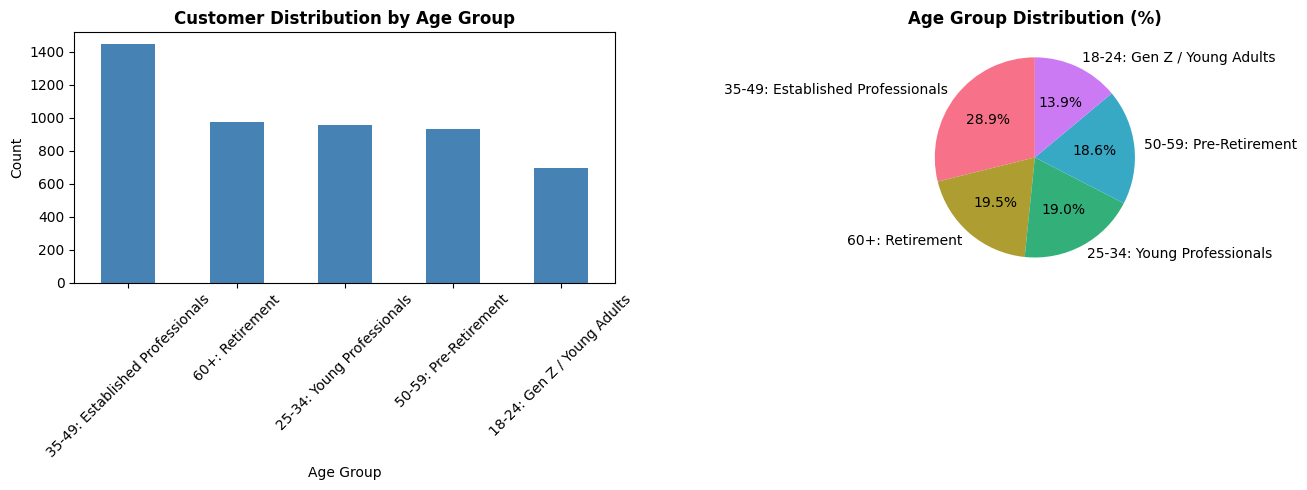

Customer Profiles by Age Group:


Age Group: 18-24: Gen Z / Young Adults
Customer Count: 697
Average Age: 21.1 years
Average Account Balance: $4938.19
Average Loan Amount: $26222.32
Average Credit Limit: $5525.99
Average Credit Card Balance: $2458.51
Loan Approval Rate: 33.6%
Average Interest Rate: 5.45%
Dominant Loan Type: Mortgage
Average Transaction Amount: $2436.61

Age Group: 25-34: Young Professionals
Customer Count: 952
Average Age: 29.4 years
Average Account Balance: $5059.58
Average Loan Amount: $26173.31
Average Credit Limit: $5545.92
Average Credit Card Balance: $2495.06
Loan Approval Rate: 36.1%
Average Interest Rate: 5.42%
Dominant Loan Type: Mortgage
Average Transaction Amount: $2509.56

Age Group: 35-49: Established Professionals
Customer Count: 1444
Average Age: 42.0 years
Average Account Balance: $5091.02
Average Loan Amount: $25521.79
Average Credit Limit: $5493.26
Average Credit Card Balance: $2484.54
Loan Approval Rate: 33.2%
Average Interest Rate: 5.54%
Dominant Lo

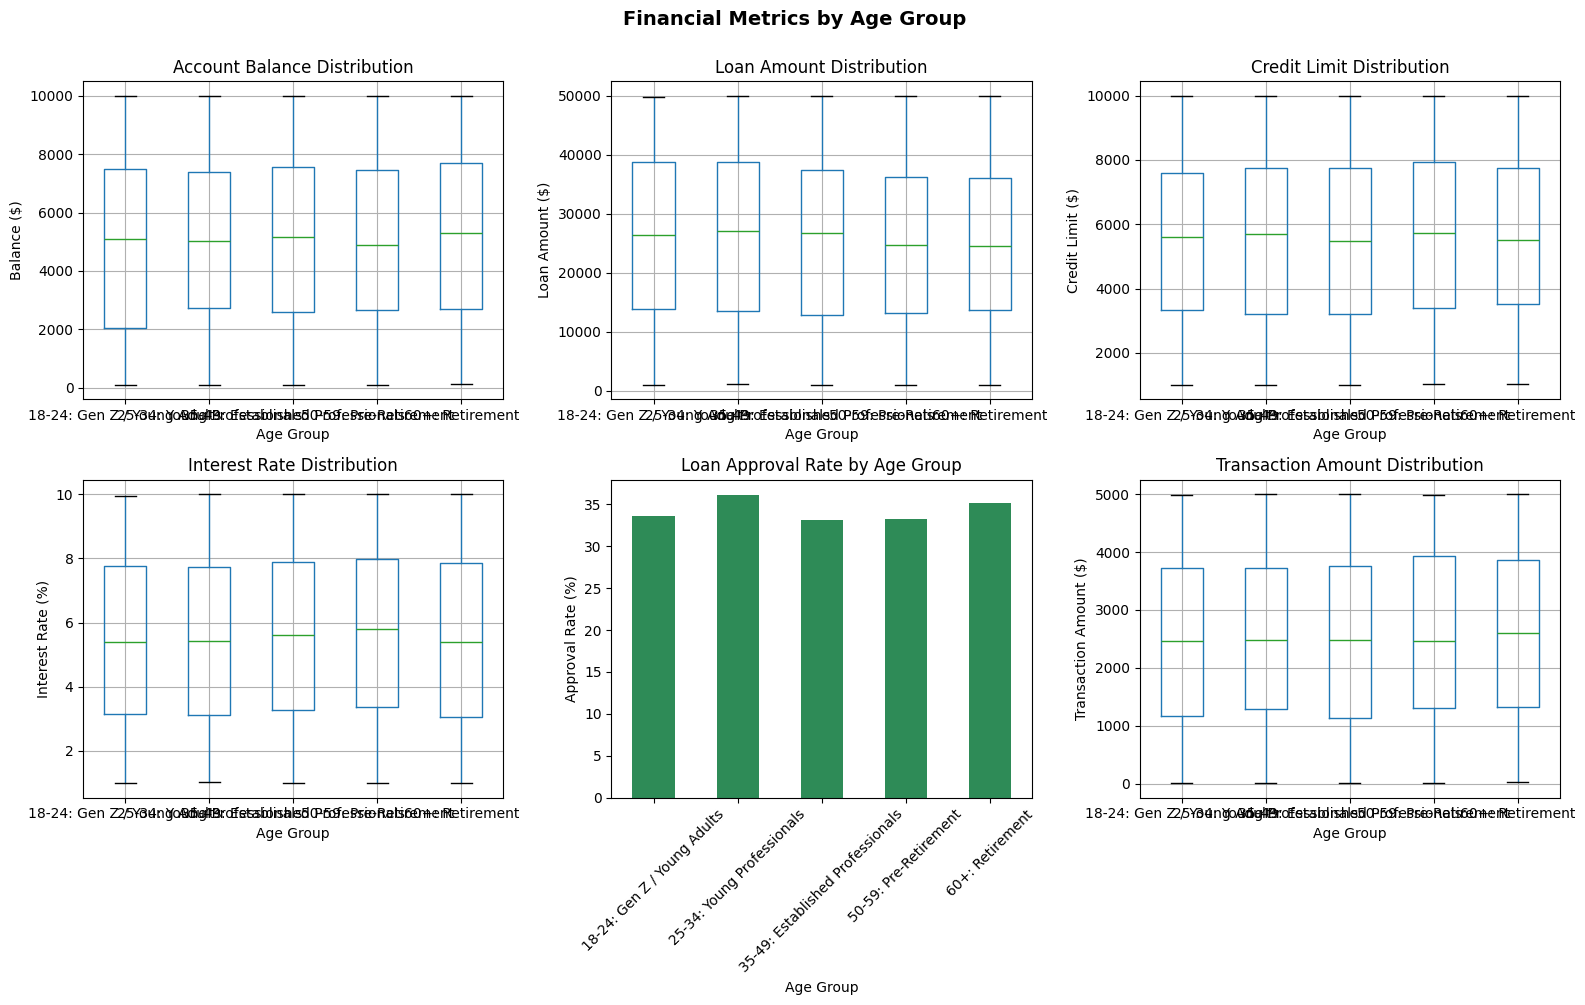

Risk Score Statistics by Age Group:
                                       mean  min  max        std
Age_Group                                                       
18-24: Gen Z / Young Adults       43.350072   15   95  16.716989
25-34: Young Professionals        28.314076    0   80  16.562316
35-49: Established Professionals  27.683518    0   80  17.214685
50-59: Pre-Retirement             27.526824    0   80  16.435086
60+: Retirement                   31.205128    0   85  17.886505


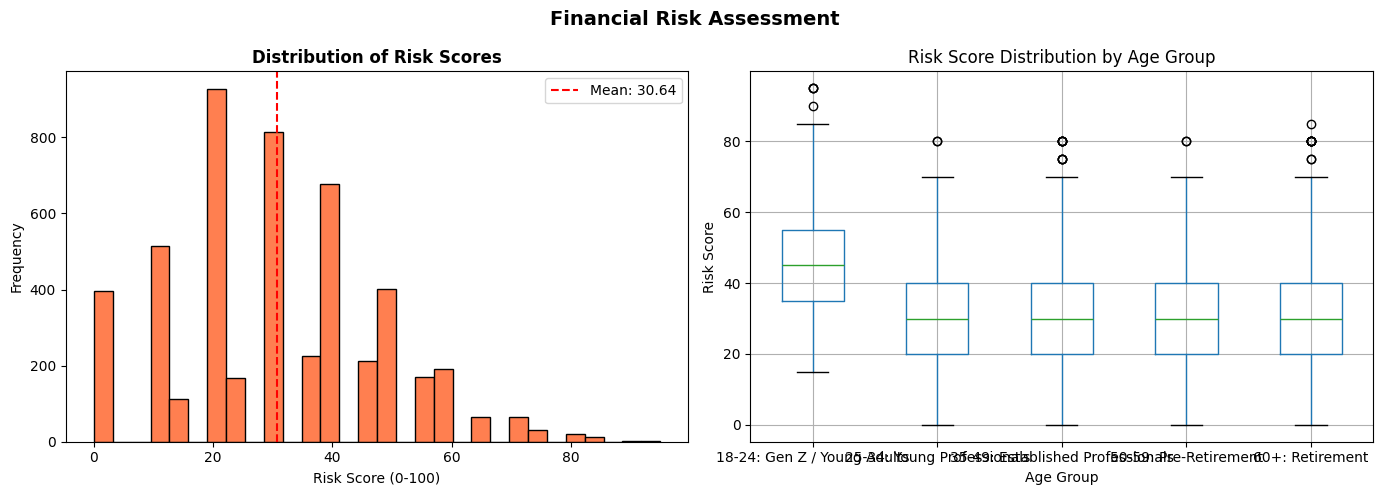

Training dataset saved to data/phi3_training_data.csv! Shape: (5000, 13)
K-Means Clustering Results:

Cluster distribution:
Cluster
0     979
1    1006
2     999
3    1018
4     998
Name: count, dtype: int64

Cluster Characteristics:


Cluster 0 (Size: 979 customers)
Average Account Balance: $2486.23
Average Loan Amount: $36415.01
Average Credit Limit: $5859.93
Average Interest Rate: 5.64%

Dominant Age Groups:
  - 35-49: Established Professionals: 279 (28.5%)
  - 25-34: Young Professionals: 188 (19.2%)
  - 60+: Retirement: 183 (18.7%)
  - 50-59: Pre-Retirement: 181 (18.5%)
  - 18-24: Gen Z / Young Adults: 148 (15.1%)

Cluster 1 (Size: 1006 customers)
Average Account Balance: $4158.74
Average Loan Amount: $10702.08
Average Credit Limit: $7564.88
Average Interest Rate: 5.36%

Dominant Age Groups:
  - 35-49: Established Professionals: 293 (29.1%)
  - 50-59: Pre-Retirement: 204 (20.3%)
  - 25-34: Young Professionals: 196 (19.5%)
  - 60+: Retirement: 194 (19.3%)
  - 18-24: Gen Z / Young Ad

In [15]:
"""
Main function to orchestrate the entire Phi-3 model preparation pipeline.
"""

print("Starting Phi-3 Financial Recommendation Model Preparation...\n")
DATA_PATH = Path("data") / "Comprehensive_Banking_Database.csv"
# Load dataset
df = load_dataset("data/Comprehensive_Banking_Database.csv")

# Apply age grouping
df = apply_age_grouping(df)
visualize_age_groups(df)

# Create age group profiles
age_group_profiles = create_age_group_profiles(df)
comparison_df = create_comparison_dataframe(age_group_profiles)

# Visualize financial metrics
visualize_financial_metrics(df)

# Calculate risk scores
df = add_risk_scores(df, age_group_profiles)
visualize_risk_scores(df)

# Create training data
training_df = create_training_dataset_csv(
    df, age_group_profiles, "data/phi3_training_data.csv"
)

# Perform clustering
df, kmeans, scaler = perform_kmeans_clustering(df)
analyze_clusters(df)

# Save clustered data
df.to_csv("data/banking_data_with_clusters.csv", index=False)
print("\nClustered dataset saved!")

# Create enhanced training data
enhanced_training_data = create_enhanced_training_data_jsonl(
    df, age_group_profiles, "data/phi3_enhanced_training_data.jsonl"
)

# Create summary statistics
summary_df = create_age_group_summary(df, "data/age_group_summary.csv")

# Print final summary
print_final_summary(df, training_df, len(enhanced_training_data), age_group_profiles)